# 1.2 — Generación de etiquetas no supervisadas para Malignant

**Objetivo**: Generar etiquetas de cluster para las muestras Malignant de forma
**totalmente independiente** entre train y test (sin filtración de información).

Pipeline por conjunto: `log1p → StandardScaler → PCA(90%) → search_best_clustering`

El número óptimo de clusters (k) se determina automáticamente en train usando
métricas internas (silhouette, Calinski–Harabasz, Davies–Bouldin). Se aplica el
mismo k al conjunto de test con pipeline independiente.

Las etiquetas se alinean entre conjuntos mediante el algoritmo húngaro sobre la
similitud coseno de las distribuciones de `Patient_group` por cluster.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

from genomics_dl.models.heterogeneity import (
    generate_malignant_clusters,
    generate_malignant_clusters_fixed_k,
    align_malignant_cluster_labels,
    compute_umap_from_pca,
    plot_umap,
)
from genomics_dl.models.train_multiclass import build_y_multiclass_with_malignant_clusters

In [3]:
DATA_PROCESSED = Path("../data/processed")

TRAIN_PATH = DATA_PROCESSED / "gse183635_tep_tpm_train.parquet"
TEST_PATH  = DATA_PROCESSED / "gse183635_tep_tpm_test.parquet"

OUT_TRAIN = DATA_PROCESSED / "gse183635_tep_tpm_train_clustered.parquet"
OUT_TEST  = DATA_PROCESSED / "gse183635_tep_tpm_test_clustered.parquet"

RANDOM_STATE = 42
PCA_VARIANCE = 0.90
N_CLUSTERS_RANGE = range(2, 11)

metadata_cols = [
    "Sample ID", "Patient_group", "Stage", "Sex", "Age",
    "Sample-supplying institution", "Training series",
    "Evaluation series", "Validation series", "lib.size",
    "classificationScoreCancer", "Class_group",
]

## Carga de datos

In [4]:
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

if "Sample ID" in df_train.columns:
    df_train = df_train.set_index("Sample ID", drop=False)
if "Sample ID" in df_test.columns:
    df_test = df_test.set_index("Sample ID", drop=False)

gene_cols = [c for c in df_train.columns if c not in metadata_cols]

print(f"Train: {len(df_train)} muestras, Test: {len(df_test)} muestras")
print(f"Genes: {len(gene_cols)}")

Train: 1880 muestras, Test: 471 muestras
Genes: 5440


## Filtrar muestras Malignant

In [5]:
mask_mal_train = df_train["Class_group"] == "Malignant"
mask_mal_test  = df_test["Class_group"] == "Malignant"

X_mal_train = df_train.loc[mask_mal_train, gene_cols]
X_mal_test  = df_test.loc[mask_mal_test, gene_cols]

meta_mal_train = df_train.loc[mask_mal_train, metadata_cols].copy()
meta_mal_test  = df_test.loc[mask_mal_test, metadata_cols].copy()

print(f"Malignant train: {X_mal_train.shape}")
print(f"Malignant test:  {X_mal_test.shape}")

Malignant train: (1302, 5440)
Malignant test:  (326, 5440)


## Búsqueda automática de clusters en TRAIN

In [6]:
labels_train, scaler_train, pca_train, best_summary, df_search = generate_malignant_clusters(
    X_mal_train,
    pca_variance=PCA_VARIANCE,
    n_clusters_range=N_CLUSTERS_RANGE,
    random_state=RANDOM_STATE,
    verbose=True,
)

print(f"\nTrain — PCA componentes: {pca_train.n_components_}")
print(f"Train — Mejor modelo: {best_summary['modelo']}, k={best_summary['n_clusters']}, "
      f"silhouette={best_summary['silhouette']:.4f}")
print(f"Train — distribución: {dict(zip(*np.unique(labels_train, return_counts=True)))}")

n=2 | kmeans sil=0.252, gmm sil=0.252, agg_ward sil=0.209 
n=3 | kmeans sil=0.251, gmm sil=0.251, agg_ward sil=0.246 
n=4 | kmeans sil=0.115, gmm sil=0.115, agg_ward sil=0.247 
n=5 | kmeans sil=0.111, gmm sil=0.111, agg_ward sil=0.110 
n=6 | kmeans sil=0.110, gmm sil=0.110, agg_ward sil=0.072 
n=7 | kmeans sil=0.111, gmm sil=0.111, agg_ward sil=0.075 
n=8 | kmeans sil=0.062, gmm sil=0.062, agg_ward sil=0.058 
n=9 | kmeans sil=0.060, gmm sil=0.060, agg_ward sil=0.046 
n=10 | kmeans sil=0.066, gmm sil=0.066, agg_ward sil=0.049 

Mejor configuración:
{'modelo': 'kmeans', 'n_clusters': 2, 'params': {'n_clusters': 2}, 'silhouette': 0.2521627481930177, 'calinski_harabasz': 357.547497718241, 'davies_bouldin': 1.6676491896062893}

Train — PCA componentes: 507
Train — Mejor modelo: kmeans, k=2, silhouette=0.2522
Train — distribución: {np.int32(0): np.int64(867), np.int32(1): np.int64(435)}


In [7]:
# Tabla de resultados de la búsqueda
print("Resultados de la búsqueda de clustering (top 10 por silhouette):")
display(df_search.sort_values("silhouette", ascending=False).head(10))

Resultados de la búsqueda de clustering (top 10 por silhouette):


,modelo,n_clusters,params,silhouette,calinski_harabasz,davies_bouldin
0,kmeans,2,{'n_clusters': 2},0.252163,357.547498,1.667649
1,gmm,2,"{'n_components': 2, 'covariance_type': 'full'}",0.252163,357.547498,1.667649
3,kmeans,3,{'n_clusters': 3},0.250683,280.095797,1.972381
4,gmm,3,"{'n_components': 3, 'covariance_type': 'full'}",0.250683,280.095797,1.972381
8,agglomerative_ward,4,"{'n_clusters': 4, 'linkage': 'ward'}",0.246972,191.105984,2.358377
5,agglomerative_ward,3,"{'n_clusters': 3, 'linkage': 'ward'}",0.246075,248.442295,2.041652
2,agglomerative_ward,2,"{'n_clusters': 2, 'linkage': 'ward'}",0.208956,270.094615,1.450786
6,kmeans,4,{'n_clusters': 4},0.114652,217.765630,2.033780
7,gmm,4,"{'n_components': 4, 'covariance_type': 'full'}",0.114652,217.765630,2.033780
15,kmeans,7,{'n_clusters': 7},0.110667,137.906857,2.480328


## Clustering en TEST (mismo k, pipeline independiente)

In [8]:
best_k = int(best_summary["n_clusters"])
print(f"Aplicando k={best_k} (seleccionado en train) al conjunto de test...\n")

labels_test, scaler_test, pca_test = generate_malignant_clusters_fixed_k(
    X_mal_test,
    n_clusters=best_k,
    pca_variance=PCA_VARIANCE,
    random_state=RANDOM_STATE,
)
print(f"Test — PCA componentes: {pca_test.n_components_}")
print(f"Test — distribución: {dict(zip(*np.unique(labels_test, return_counts=True)))}")

Aplicando k=2 (seleccionado en train) al conjunto de test...

Test — PCA componentes: 151
Test — distribución: {np.int32(0): np.int64(208), np.int32(1): np.int64(118)}


## Alineación de etiquetas (algoritmo húngaro)

In [9]:
labels_train_al, labels_test_al = align_malignant_cluster_labels(
    labels_train, labels_test,
    meta_mal_train, meta_mal_test,
    patient_group_col="Patient_group",
)

print("Train alineado:", dict(zip(*np.unique(labels_train_al, return_counts=True))))
print("Test alineado: ", dict(zip(*np.unique(labels_test_al, return_counts=True))))

Train alineado: {np.int32(0): np.int64(867), np.int32(1): np.int64(435)}
Test alineado:  {np.int32(0): np.int64(208), np.int32(1): np.int64(118)}


## Validación: crosstab Patient_group (tipo de cáncer) × cluster

In [10]:
meta_mal_train["mal_cluster"] = labels_train_al
meta_mal_test["mal_cluster"]  = labels_test_al

print("=== TRAIN ===")
ct_train = pd.crosstab(meta_mal_train["mal_cluster"], meta_mal_train["Patient_group"])
display(ct_train)

chi2_tr, p_tr, _, _ = chi2_contingency(ct_train)
print(f"Chi2 Patient_group vs cluster (train): {chi2_tr:.2f}, p={p_tr:.2e}")

print("\n=== TEST ===")
ct_test = pd.crosstab(meta_mal_test["mal_cluster"], meta_mal_test["Patient_group"])
display(ct_test)

chi2_te, p_te, _, _ = chi2_contingency(ct_test)
print(f"Chi2 Patient_group vs cluster (test): {chi2_te:.2f}, p={p_te:.2e}")

=== TRAIN ===


Patient_group,Breast cancer,Cholangiocarcinoma,Colorectal cancer,Endometrial cancer,Esophageal carcinoma,Glioma,Head and neck cancer,Hepatocellular carcinoma,Lymphoma,Melanoma,Multiple Myeloma,Non-small-cell lung cancer,Ovarian cancer,Pancreatic cancer,Prostate cancer,Renal cell cancer,Sarcoma,Urothelial cancer
mal_cluster,,,,,,,,,,,,,,,,,,
0,76,62,62,17,4,79,24,19,14,42,9,247,92,74,13,17,11,5
1,4,9,7,17,8,34,55,0,2,12,13,170,22,19,10,3,33,17


Chi2 Patient_group vs cluster (train): 223.78, p=4.52e-38

=== TEST ===


Patient_group,Breast cancer,Cholangiocarcinoma,Colorectal cancer,Endometrial cancer,Esophageal carcinoma,Glioma,Head and neck cancer,Hepatocellular carcinoma,Lymphoma,Melanoma,Multiple Myeloma,Non-small-cell lung cancer,Ovarian cancer,Pancreatic cancer,Prostate cancer,Renal cell cancer,Sarcoma,Urothelial cancer
mal_cluster,,,,,,,,,,,,,,,,,,
0,13,13,14,3,0,12,6,4,3,12,1,67,22,24,2,8,2,2
1,0,1,2,2,3,7,16,0,1,2,8,38,8,9,10,0,7,4


Chi2 Patient_group vs cluster (test): 78.19, p=8.04e-10


## Validación: crosstab Institución × cluster

In [11]:
print("=== TRAIN ===")
display(pd.crosstab(meta_mal_train["mal_cluster"], meta_mal_train["Sample-supplying institution"]))

print("\n=== TEST ===")
display(pd.crosstab(meta_mal_test["mal_cluster"], meta_mal_test["Sample-supplying institution"]))

=== TRAIN ===


Sample-supplying institution,Institute 1,Institute 11,Institute 12,Institute 13,Institute 2,Institute 3,Institute 4,Institute 5,Institute 6,Institute 7,Institute 8,Institute 9
mal_cluster,,,,,,,,,,,,
0,13,8,7,389,33,23,284,38,1,4,20,47
1,3,7,1,157,29,3,12,144,4,1,30,44



=== TEST ===


Sample-supplying institution,Institute 1,Institute 11,Institute 13,Institute 2,Institute 3,Institute 4,Institute 5,Institute 7,Institute 8,Institute 9
mal_cluster,,,,,,,,,,
0,6,1,96,7,6,65,9,1,6,11
1,1,3,46,3,0,2,38,2,12,11


## UMAP — Visualización de clusters

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


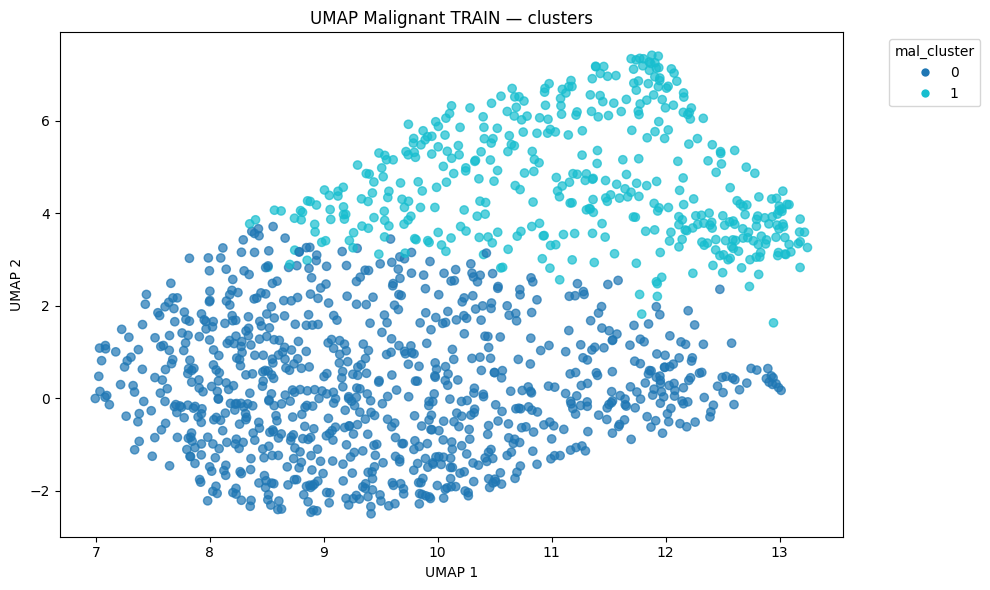

In [12]:
# UMAP para train
X_log_train = np.log1p(X_mal_train.values)
X_scaled_train = scaler_train.transform(X_log_train)
X_pca_train = pca_train.transform(X_scaled_train)

X_umap_train, _ = compute_umap_from_pca(X_pca_train, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_train,
    color=pd.Series(labels_train_al, index=meta_mal_train.index, name="mal_cluster"),
    title="UMAP Malignant TRAIN — clusters",
    figsize=(10, 6),
)

/workspaces/TFM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


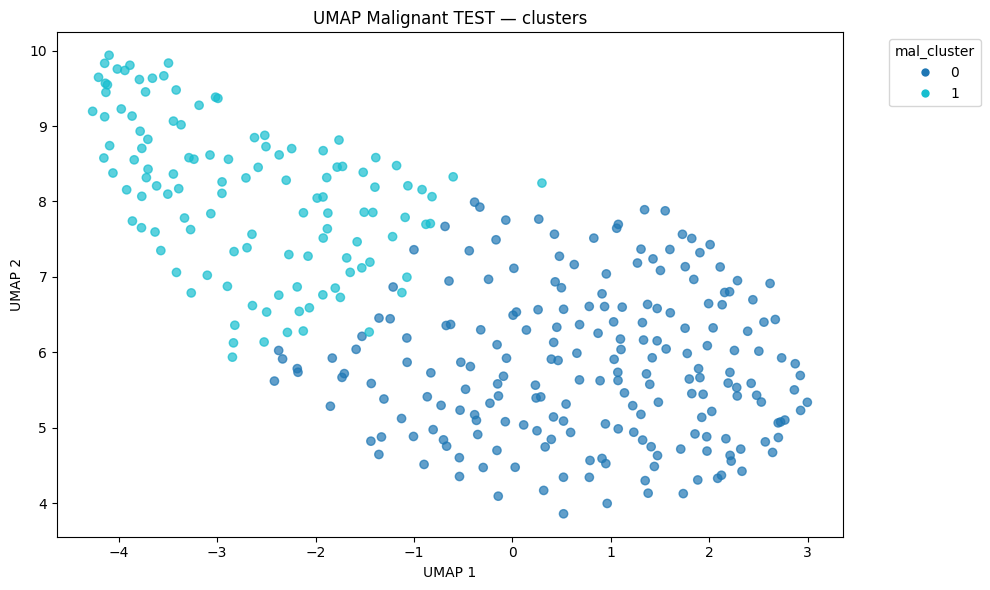

In [13]:
# UMAP para test
X_log_test = np.log1p(X_mal_test.values)
X_scaled_test = scaler_test.transform(X_log_test)
X_pca_test = pca_test.transform(X_scaled_test)

X_umap_test, _ = compute_umap_from_pca(X_pca_test, random_state=RANDOM_STATE)

plot_umap(
    X_umap=X_umap_test,
    color=pd.Series(labels_test_al, index=meta_mal_test.index, name="mal_cluster"),
    title="UMAP Malignant TEST — clusters",
    figsize=(10, 6),
)

## Guardar datos enriquecidos con clusters

In [14]:
# Añadir columna mal_cluster (NaN para nonMalignant)
df_train["mal_cluster"] = np.nan
df_train.loc[mask_mal_train, "mal_cluster"] = labels_train_al.astype(float)

df_test["mal_cluster"] = np.nan
df_test.loc[mask_mal_test, "mal_cluster"] = labels_test_al.astype(float)

print("Train mal_cluster:")
print(df_train["mal_cluster"].value_counts(dropna=False))
print("\nTest mal_cluster:")
print(df_test["mal_cluster"].value_counts(dropna=False))

Train mal_cluster:
mal_cluster
0.0    867
NaN    578
1.0    435
Name: count, dtype: int64

Test mal_cluster:
mal_cluster
0.0    208
NaN    145
1.0    118
Name: count, dtype: int64


In [15]:
df_train.to_parquet(OUT_TRAIN, index=False)
df_test.to_parquet(OUT_TEST, index=False)

print(f"Guardado: {OUT_TRAIN}")
print(f"Guardado: {OUT_TEST}")

Guardado: ../data/processed/gse183635_tep_tpm_train_clustered.parquet
Guardado: ../data/processed/gse183635_tep_tpm_test_clustered.parquet


## Preview: distribución de clases con clusters malignos

In [16]:
y_train_clust = build_y_multiclass_with_malignant_clusters(
    df_train,
    class_group_col="Class_group",
    patient_group_col="Patient_group",
    cluster_col="mal_cluster",
)

print(f"Distribución de clases (train, {len(np.unique(y_train_clust))} clases):")
print(pd.Series(y_train_clust).value_counts())

y_test_clust = build_y_multiclass_with_malignant_clusters(
    df_test,
    class_group_col="Class_group",
    patient_group_col="Patient_group",
    cluster_col="mal_cluster",
)

print(f"\nDistribución de clases (test, {len(np.unique(y_test_clust))} clases):")
print(pd.Series(y_test_clust).value_counts())

Distribución de clases (train, 3 clases):
Malignant_0     867
nonMalignant    578
Malignant_1     435
Name: count, dtype: int64

Distribución de clases (test, 3 clases):
Malignant_0     208
nonMalignant    145
Malignant_1     118
Name: count, dtype: int64
